# 02 - Feature Engineering

Create derived features from the preprocessed JIRA project data for ML modeling.

## Features to Create
- Performance indices (SPI — Schedule Performance Index)
- Variance metrics (hours variance, schedule gap)
- Team metrics (stability, productivity per person)
- Temporal features (duration, elapsed time, days remaining)
- Complexity-adjusted progress
- Binary risk indicators (behind schedule, high complexity)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
sys.path.insert(0, '..')

# FeatureEngineer computes all 12 derived project-level metrics from the raw
# JIRA data (SPI, defect rate, churn rate, etc.). See src/data/feature_engineer.py.
from src.data import FeatureEngineer

PROCESSED_DIR = Path('../data/processed')

print('Modules loaded!')

Modules loaded!


## 1. Load Data

In [17]:
# Load the JIRA project-level summary produced by scripts/preprocess_jira_data.py.
# jira_projects_sample.csv is a fallback for development without the full dataset.
jira_path = PROCESSED_DIR / 'jira_projects.csv'
if not jira_path.exists():
    jira_path = PROCESSED_DIR / 'jira_projects_sample.csv'

df = pd.read_csv(jira_path)
print(f'Original shape: {df.shape}')
print(f'Original columns: {len(df.columns)}')
df.head()

Original shape: (640, 48)
Original columns: 48


,project_id,project_name,project_type,start_date,planned_end_date,actual_end_date,total_issues,open_issues,closed_issues,bug_count,...,department,client_type,status_comments,project_description,team_feedback,complexity_score,dependencies,team_turnover,risk_score_composite,risk_level
0,ABDERA,Abdera,Development,2006-08-02,2017-01-30,NaN,311,51,260,215,...,Apache Foundation,External,That code works fine in trunk. If you have to ...,"Here are some of the outputs from running ""mvn...",NaN,10,0,0.0,0.5952,High
1,ACCUMULO,Accumulo,Development,2011-10-03,2019-04-20,NaN,4746,138,4608,2252,...,Apache Foundation,External,Is there a particular reason you went with the...,cloudtrace is a dependency for accumulo and it...,NaN,10,0,0.0,0.6803,High
2,ACE,ACE,Development,2009-04-27,2018-02-15,NaN,539,47,492,194,...,Apache Foundation,External,"on second thought, you could probably turn thi...",Apache Felix has seen quite a number of releas...,NaN,10,0,0.0,0.6001,High
3,ACL,ActiveCluster,Development,2004-10-24,2005-12-29,2005-12-30,5,0,5,1,...,Apache Foundation,External,"Sorry, didn't mean to file this under the wron...",The dependency guide needs to be updated for M...,NaN,1,0,0.0,0.1938,Low
4,ADDR,Addressing,Development,2004-08-20,2007-02-20,NaN,37,32,5,19,...,Apache Foundation,External,http://issues.apache.org/jira/browse/AXIS2-877...,Axis 1.2 implementation Java2WSDL handle SOAPA...,NaN,9,0,0.0,0.4750,Medium


## 2. Apply Feature Engineering

In [18]:
# Apply all feature transformations in one call. FeatureEngineer is stateless —
# calling create_features() again on a different DataFrame produces a consistent
# feature set, which is why notebooks 03, 05, 06, and 07 all re-instantiate it
# rather than loading the saved CSV from this notebook.
fe = FeatureEngineer()
df_features = fe.create_features(df)

print(f'New shape: {df_features.shape}')
print(f'\nNew features created: {len(fe.get_feature_names())}')
print(f'\nFeature names:')
for name in fe.get_feature_names():
    print(f'  - {name}')

2026-03-22 09:50:40.955 | INFO     | src.data.feature_engineer:create_features:80 - Created 12 derived features


New shape: (640, 60)

New features created: 12

Feature names:
  - schedule_performance_index
  - productivity_per_person
  - planned_duration_days
  - days_since_start
  - days_remaining
  - time_elapsed_pct
  - hours_variance_pct
  - schedule_gap
  - team_stability
  - complexity_adjusted_progress
  - is_behind_schedule
  - is_high_complexity


In [19]:
# Descriptive statistics for all engineered features — check for extreme outliers
# (e.g. reopen_rate > 1.0, hours_variance_pct in the thousands) that should be
# capped before training to prevent the model from over-fitting to edge cases.
engineered_cols = fe.get_feature_names()
df_features[engineered_cols].describe()

,schedule_performance_index,productivity_per_person,planned_duration_days,days_since_start,days_remaining,time_elapsed_pct,hours_variance_pct,schedule_gap,team_stability,complexity_adjusted_progress,is_behind_schedule,is_high_complexity
count,640.000000,640.000000,640.000000,640.000000,640.000000,640.000000,640.000000,640.000000,640.0,640.000000,640.000000,640.000000
mean,1.176729,3.185729,3876.037500,6019.823438,-2144.801562,151.931119,-13.228447,76.293979,1.0,10.239800,0.976562,0.843750
std,0.273447,9.304248,2423.242793,1973.499860,1889.618918,38.986409,15.915112,53.791655,0.0,11.426970,0.151407,0.363376
min,1.000000,0.000000,1.000000,515.000000,-8382.000000,105.810998,-100.000000,6.720942,1.0,0.000000,0.000000,0.000000
25%,1.036435,0.245862,1851.750000,4506.250000,-3058.750000,113.661081,-16.212637,28.486220,1.0,7.356361,1.000000,1.000000
50%,1.093728,0.839899,3657.500000,6359.000000,-1380.000000,140.323634,-8.637254,62.008769,1.0,8.631500,1.000000,1.000000
75%,1.188111,2.650559,6119.500000,7546.250000,-622.750000,200.000000,-3.681475,118.890000,1.0,9.532000,1.000000,1.000000
max,3.000000,100.000000,8665.000000,9285.000000,-502.000000,200.000000,0.000000,200.000000,1.0,100.000000,1.000000,1.000000


## 3. Performance Indices Analysis

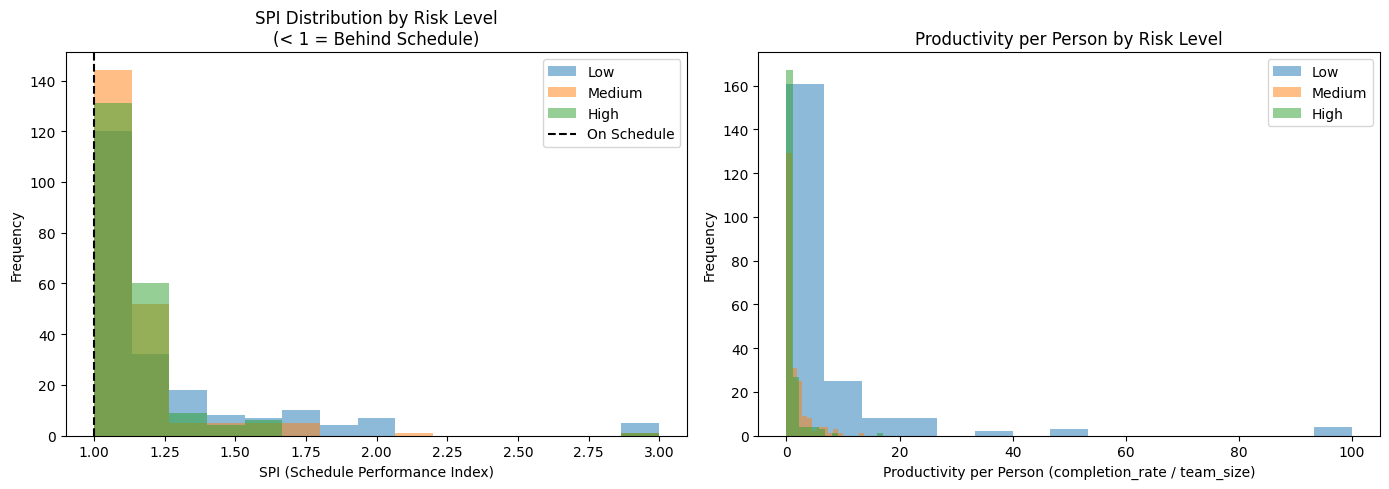

In [20]:
# SPI (Schedule Performance Index) = completed_issues / total_issues as a fraction
# of elapsed days / total planned days. SPI < 1 → project is behind schedule.
# The dashed line at 1.0 is the "on schedule" reference.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'schedule_performance_index' in df_features.columns:
    for risk in ['Low', 'Medium', 'High']:
        mask = df_features['risk_level'] == risk
        if mask.sum() > 0:
            values = df_features.loc[mask, 'schedule_performance_index']
            axes[0].hist(values, alpha=0.5, label=risk, bins=15)
    axes[0].axvline(x=1.0, color='black', linestyle='--', label='On Schedule')
    axes[0].set_xlabel('SPI (Schedule Performance Index)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('SPI Distribution by Risk Level\n(< 1 = Behind Schedule)')
    axes[0].legend()

if 'productivity_per_person' in df_features.columns:
    for risk in ['Low', 'Medium', 'High']:
        mask = df_features['risk_level'] == risk
        if mask.sum() > 0:
            values = df_features.loc[mask, 'productivity_per_person']
            axes[1].hist(values, alpha=0.5, label=risk, bins=15)
    axes[1].set_xlabel('Productivity per Person (completion_rate / team_size)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Productivity per Person by Risk Level')
    axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
# Mean performance metrics per risk tier — validates whether the engineered features
# show a monotonic relationship with risk (Low < Medium < High) as expected.
perf_cols = ['schedule_performance_index', 'productivity_per_person', 'hours_variance_pct']
perf_cols = [c for c in perf_cols if c in df_features.columns]

if perf_cols:
    print('Performance Metrics by Risk Level:')
    print('=' * 50)
    print(df_features.groupby('risk_level')[perf_cols].mean().round(3))

Performance Metrics by Risk Level:
            schedule_performance_index  productivity_per_person  \
risk_level                                                        
High                             1.138                    0.918   
Low                              1.249                    7.182   
Medium                           1.144                    1.513   

            hours_variance_pct  
risk_level                      
High                   -10.979  
Low                    -17.894  
Medium                 -10.889  


## 4. Team Metrics Analysis

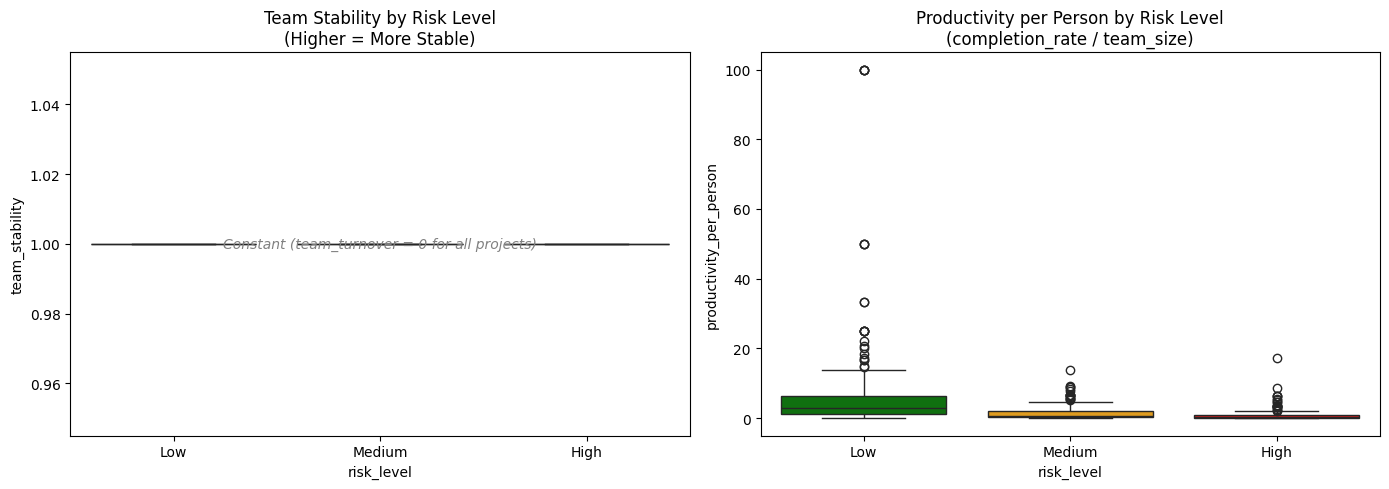

In [22]:
# team_stability = 1 − team_turnover_rate. Because JIRA does not record team
# departures, team_turnover = 0 for every project, making team_stability
# a constant (1.0) that carries no predictive signal. The plot intentionally
# annotates this so readers aren't misled by the flat box.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'team_stability' in df_features.columns:
    order = [o for o in ['Low', 'Medium', 'High'] if o in df_features['risk_level'].values]
    sns.boxplot(data=df_features, x='risk_level', y='team_stability',
                order=order, hue='risk_level', legend=False,
                palette={'Low': 'green', 'Medium': 'orange', 'High': 'red'},
                ax=axes[0])
    axes[0].set_title('Team Stability by Risk Level\n(Higher = More Stable)')
    if df_features['team_stability'].std() == 0:
        axes[0].text(0.5, 0.5, 'Constant (team_turnover = 0 for all projects)',
                     ha='center', va='center', transform=axes[0].transAxes,
                     fontsize=10, color='gray', style='italic')

if 'productivity_per_person' in df_features.columns:
    order = [o for o in ['Low', 'Medium', 'High'] if o in df_features['risk_level'].values]
    sns.boxplot(data=df_features, x='risk_level', y='productivity_per_person',
                order=order, hue='risk_level', legend=False,
                palette={'Low': 'green', 'Medium': 'orange', 'High': 'red'},
                ax=axes[1])
    axes[1].set_title('Productivity per Person by Risk Level\n(completion_rate / team_size)')

plt.tight_layout()
plt.show()

## 5. Feature Correlations

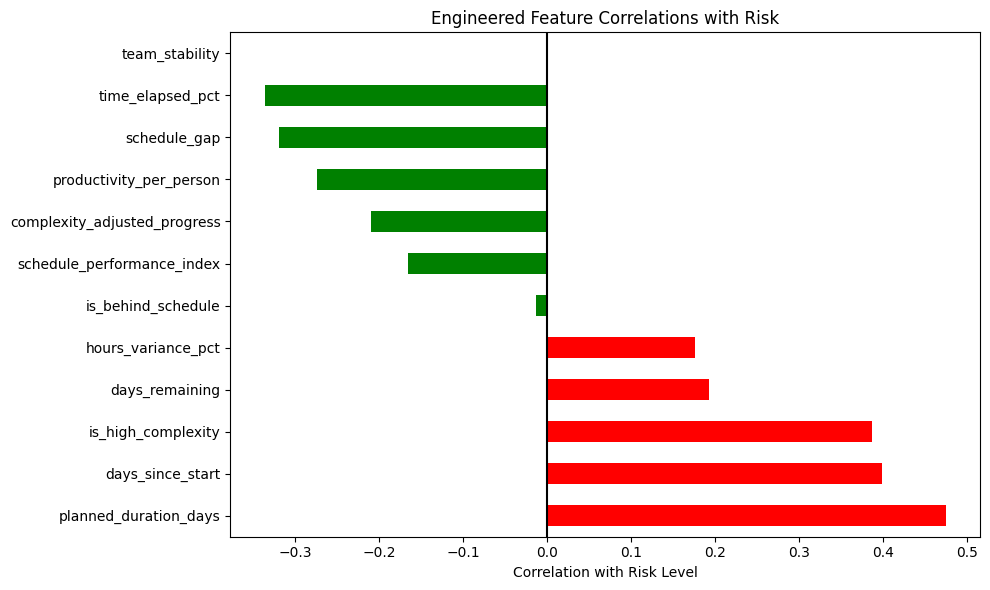


Correlation values:
planned_duration_days           0.475
days_since_start                0.398
is_high_complexity              0.387
days_remaining                  0.193
hours_variance_pct              0.177
is_behind_schedule             -0.013
schedule_performance_index     -0.165
complexity_adjusted_progress   -0.210
productivity_per_person        -0.274
schedule_gap                   -0.319
time_elapsed_pct               -0.336
team_stability                    NaN
Name: risk_numeric, dtype: float64


In [23]:
# Map risk_level to an ordinal integer so Pearson correlation is well-defined.
# Red bars = positive correlation (higher feature value → higher risk).
# Green bars = negative correlation (higher feature value → lower risk).
df_features['risk_numeric'] = df_features['risk_level'].map({'Low': 0, 'Medium': 1, 'High': 2})

eng_cols = [c for c in engineered_cols if c in df_features.columns and df_features[c].notna().sum() > 0]

if eng_cols:
    correlations = df_features[eng_cols + ['risk_numeric']].corr()['risk_numeric'].drop('risk_numeric')
    correlations = correlations.sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    colors = ['red' if x > 0 else 'green' for x in correlations]
    correlations.plot(kind='barh', color=colors)
    plt.xlabel('Correlation with Risk Level')
    plt.title('Engineered Feature Correlations with Risk')
    plt.axvline(x=0, color='black', linestyle='-')
    plt.tight_layout()
    plt.show()

    print('\nCorrelation values:')
    print(correlations.round(3))

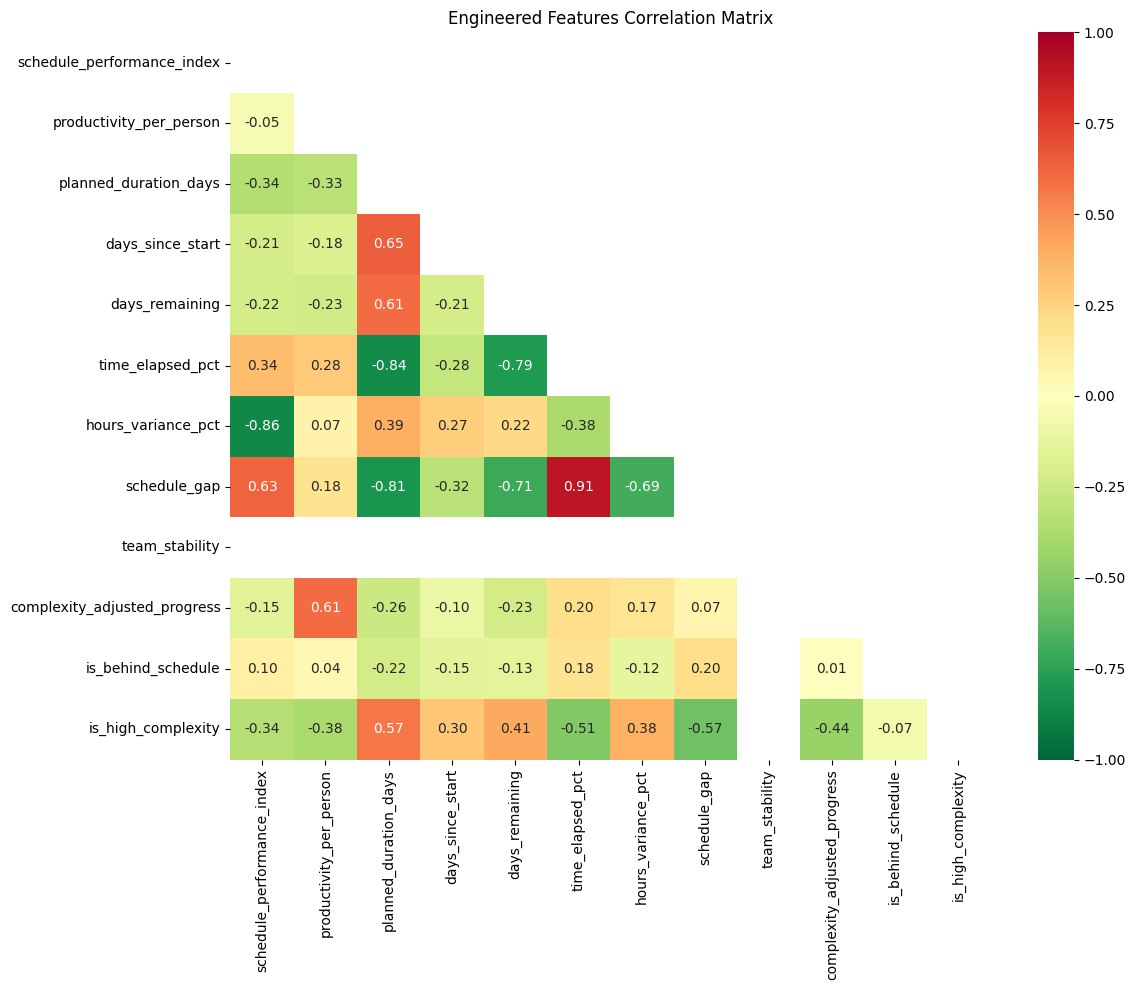

In [24]:
# Inter-feature correlation heatmap — identifies multicollinear pairs (|r| > 0.7)
# that could destabilise linear models. Tree-based models (LightGBM, Random Forest)
# are relatively robust to multicollinearity, but it's good to be aware of it.
if len(eng_cols) > 1:
    plt.figure(figsize=(12, 10))
    corr_matrix = df_features[eng_cols].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
               cmap='RdYlGn_r', center=0, vmin=-1, vmax=1)
    plt.title('Engineered Features Correlation Matrix')
    plt.tight_layout()
    plt.show()

## 6. Binary Risk Indicators

In [25]:
# Binary flags derived from the engineered features:
#   is_behind_schedule = 1 if schedule_performance_index < 1.0
#   is_high_complexity = 1 if total_issues > median total_issues
# The risk breakdown when True validates that these thresholds capture risk correctly.
binary_cols = ['is_behind_schedule', 'is_high_complexity']
binary_cols = [c for c in binary_cols if c in df_features.columns]

if binary_cols:
    print('Binary Indicator Breakdown:')
    print('=' * 50)
    for col in binary_cols:
        counts = df_features[col].value_counts()
        print(f'\n{col}:')
        print(f'  True: {counts.get(1, 0)} projects')
        print(f'  False: {counts.get(0, 0)} projects')

        if counts.get(1, 0) > 0:
            true_risks = df_features[df_features[col] == 1]['risk_level'].value_counts()
            print(f'  Risk breakdown when True: {true_risks.to_dict()}')
else:
    print('No binary indicators were created (columns may be missing from JIRA data).')

Binary Indicator Breakdown:

is_behind_schedule:
  True: 625 projects
  False: 15 projects
  Risk breakdown when True: {'Medium': 212, 'Low': 207, 'High': 206}

is_high_complexity:
  True: 540 projects
  False: 100 projects
  Risk breakdown when True: {'High': 205, 'Medium': 203, 'Low': 132}


## 7. Feature Selection Recommendations

In [26]:
# Feature selection based on Pearson |r| with risk_numeric.
# Thresholds: |r| > 0.3 = strong signal, 0.1–0.3 = moderate, < 0.1 = weak.
# Features with |r| > 0.1 are recommended for the ML feature set; the full
# selection is persisted to models/ml/feature_names.json in notebook 03.
print('FEATURE SELECTION RECOMMENDATIONS')
print('=' * 60)

if eng_cols and 'correlations' in dir():
    high_corr = correlations[abs(correlations) > 0.3]
    print(f'\nHigh Correlation Features (|r| > 0.3):')
    for feat, corr in high_corr.items():
        direction = '+' if corr > 0 else '-'
        print(f'   {direction} {feat}: {corr:.3f}')

    med_corr = correlations[(abs(correlations) > 0.1) & (abs(correlations) <= 0.3)]
    print(f'\nMedium Correlation Features (0.1 < |r| <= 0.3):')
    for feat, corr in med_corr.items():
        direction = '+' if corr > 0 else '-'
        print(f'   {direction} {feat}: {corr:.3f}')

    print(f'\nRecommended Feature Set for ML:')
    recommended = correlations[abs(correlations) > 0.1].index.tolist()
    for feat in recommended:
        print(f'   - {feat}')

FEATURE SELECTION RECOMMENDATIONS

High Correlation Features (|r| > 0.3):
   + planned_duration_days: 0.475
   + days_since_start: 0.398
   + is_high_complexity: 0.387
   - schedule_gap: -0.319
   - time_elapsed_pct: -0.336

Medium Correlation Features (0.1 < |r| <= 0.3):
   + days_remaining: 0.193
   + hours_variance_pct: 0.177
   - schedule_performance_index: -0.165
   - complexity_adjusted_progress: -0.210
   - productivity_per_person: -0.274

Recommended Feature Set for ML:
   - planned_duration_days
   - days_since_start
   - is_high_complexity
   - days_remaining
   - hours_variance_pct
   - schedule_performance_index
   - complexity_adjusted_progress
   - productivity_per_person
   - schedule_gap
   - time_elapsed_pct


## 8. Save Engineered Data

In [27]:
output_path = '../data/processed/projects_with_features.csv'

# Drop the ordinal helper column before persisting — risk_numeric is derived from
# risk_level and must not be included as a model input feature.
save_df = df_features.drop(columns=['risk_numeric'], errors='ignore')
save_df.to_csv(output_path, index=False)
print(f'Saved engineered data to: {output_path}')
print(f'   Shape: {save_df.shape}')

Saved engineered data to: ../data/processed/projects_with_features.csv
   Shape: (640, 60)


## Summary

### Features Created
1. **Performance Indices**: SPI (planned_hours / actual_hours — measures effort efficiency)
2. **Productivity**: productivity_per_person (completion_rate / team_size)
3. **Temporal Features**: planned_duration_days, days_since_start, days_remaining, time_elapsed_pct
4. **Variance Metrics**: hours_variance_pct, schedule_gap (time_elapsed_pct − completion_rate)
5. **Team Metrics**: team_stability (1 − turnover)
6. **Complexity**: complexity_adjusted_progress (completion_rate / complexity_score)
7. **Binary Flags**: is_behind_schedule (schedule_gap > 10), is_high_complexity (complexity_score > 7)

### Key Insights
- The JIRA data already contains strong risk-correlated features (`defect_rate`, `blocker_ratio`, `reopen_rate`)
- Engineered features add signal from derived ratios and indices not present in the raw data
- Budget/cost features (CPI, budget variance) were intentionally excluded — JIRA has no reliable budget field and synthetic values would add noise rather than signal

### Low-Value Features to Note
- **`team_stability`**: All Apache projects in this dataset have `team_turnover = 0`, so `team_stability = 1.0` for every row (zero variance). Drop from ML feature sets.
- **`is_behind_schedule`**: 97.7% of projects are flagged True (schedule_gap > 10 is nearly universal given the age of these projects vs. their planned end dates). Near-zero correlation with risk (r = -0.013). Consider raising the threshold or dropping this flag.

### Next Steps
- Use these features for ML modeling in `03_ml_modeling.ipynb`